## LINEAR REGRESSION
Simple Linear Regression models the relationship between **one independent
variable (X)** and **one dependent variable (Y)** by fitting a straight line
through the data.

**Equation of the line:**

Y = mX + c

**Goal:**
Find the best-fit line that minimizes the distance (error) between the
actual data points and the predicted line. This is done using the
**Least Squares Method**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

**Dataset:** insurance.csv

**Source:** [drive.google.com/file/d/1wF2p-CH3PdZTvtSmLwex9zJyR6gv2Ye-/view](https://)

Upload the CSV file manually below (Colab file upload).

In [2]:
df = pd.read_csv('/content/insurance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [3]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


age - age of the person

sex - gender of the person

bmi - body mass index of person

childern - how many childern the person have

Claim_Amount - how much amount the person claim

past_consultations

num_of steps -- indicating activity level -- higher steps -> lower risk

Hospital_expenditure - how much was the actual and total spend

NUmber_of_past_hospitalizations

Anual_Salary

##**Company wants to predict the how much amount will person claim this year based on the all above information**



In [9]:
df["children"].value_counts()

,count
children,
0.0,574
1.0,321
2.0,240
3.0,156
4.0,25
5.0,17


In [8]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


## Data Cleaning


In [10]:
'''
null values
duplicate value
outliers
data type
'''

'\nnull values\nduplicate value\noutliers\ndata type\n'

In [13]:
# check for null
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [16]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

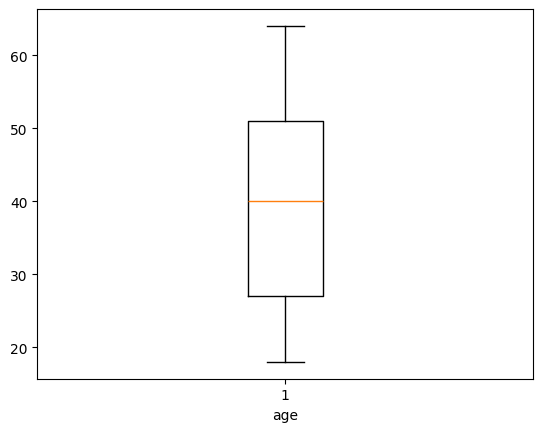

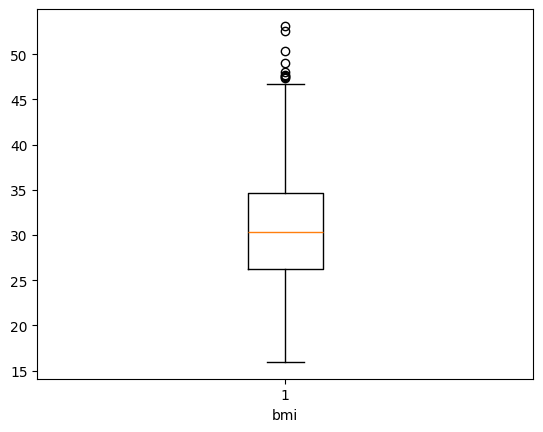

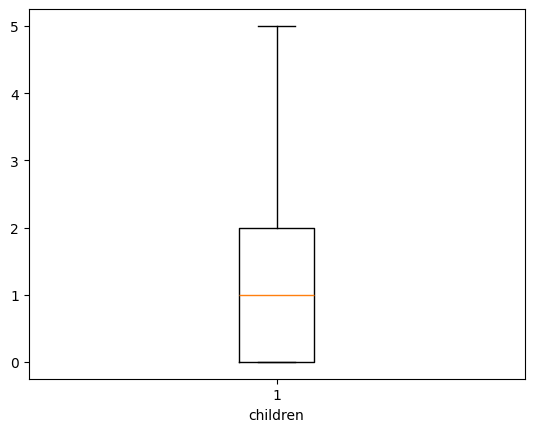

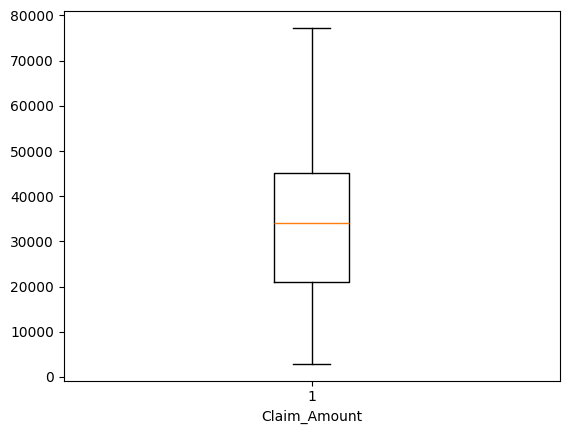

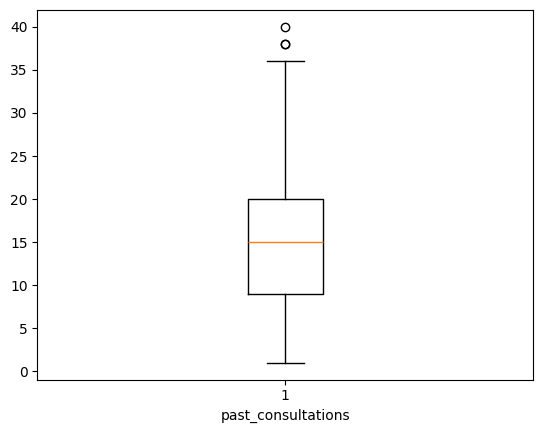

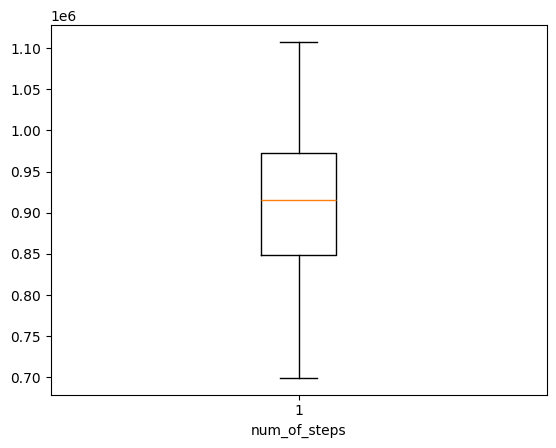

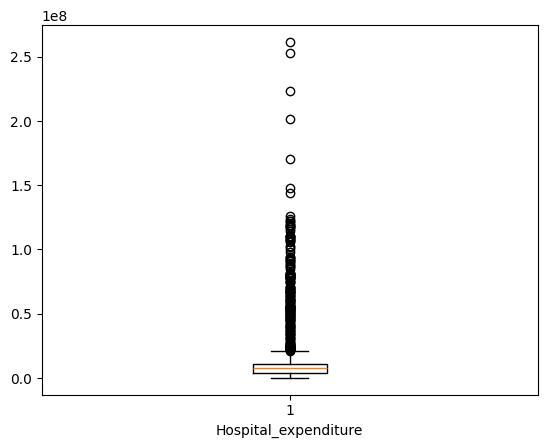

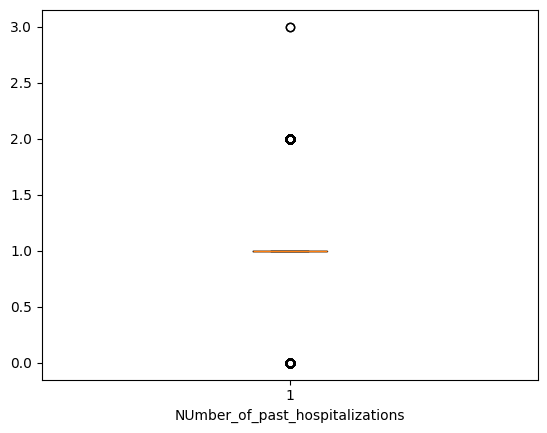

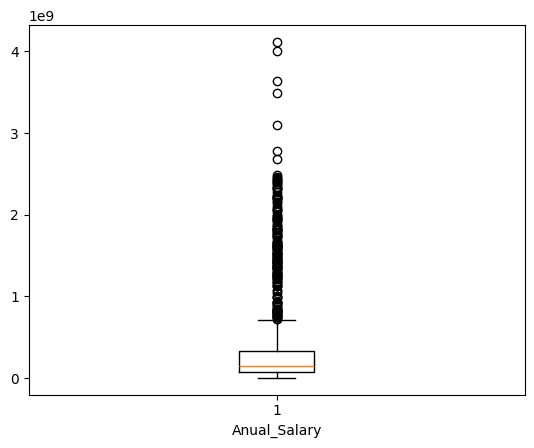

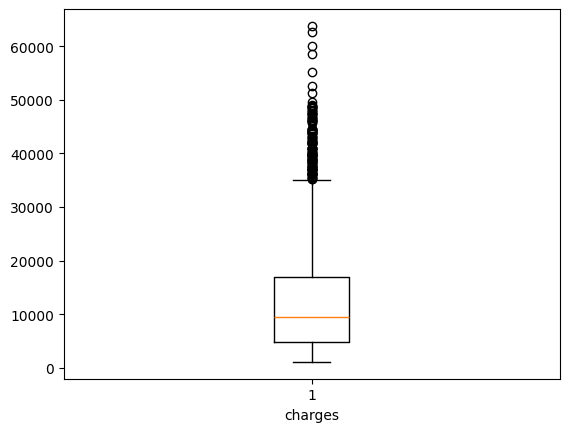

In [22]:
for col in df.columns:
  if df[col].dtype == 'float64':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# vif model
# variance inflation index -- measures the multicollinearity in data and give multicollinearity score

In [23]:
# if there is multicollinearity in data the regression model will not work well

# multicollinearity -- if independant columns are collinear with other columns (not target column)
#                      (it will be called as correlated if related with target column)

# for eg-
# monthly salary - 50k
# annual salary - 6lpa

# we can get monthly by using annualy and vice verse
# if we consider both the model will give inaccurate results

# 2nd eg - daily study hours , weekly study hours

In [25]:
'''
now to convert the dtypes
object to int/float
we use label encoder
'''

'\nnow to convert the dtypes\nobject to int/float\nwe use label encoder\n'

In [26]:
# if we have a object data type we cant use it for machines
# we need to type cast that data

In [30]:
# for vif we need to drop out target column
X = df.drop(['charges'], axis = 1)
X

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast


In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
object_cols = X.select_dtypes(include='object').columns

# Apply Label Encoding
for col in object_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("DataFrame X after label encoding:")
display(X.head())

DataFrame X after label encoding:


,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.21,0.0,0,29087.54313,17.0,4720920.992,0.0,55784970.05,2
1,18.0,1,30.14,0.0,0,39053.67437,7.0,4329831.676,0.0,13700885.19,2
2,18.0,1,33.33,0.0,0,39023.62759,19.0,6884860.774,0.0,73523107.27,2
3,18.0,1,33.66,0.0,0,28185.39332,11.0,4274773.550,0.0,75819679.60,2
4,18.0,1,34.10,0.0,0,14697.85941,16.0,3787293.921,0.0,23012320.01,2


In [41]:
vif_data = pd.DataFrame()
vif_data['column_name'] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif_data)

,column_name,VIF Values
0,age,10.736430
1,sex,1.984762
2,bmi,14.403274
3,children,1.955069
4,smoker,3.553972
5,Claim_Amount,6.464483
6,past_consultations,7.933581
7,Hospital_expenditure,30.250111
8,NUmber_of_past_hospitalizations,15.564821
9,Anual_Salary,46.506789


In [45]:
# the column with high vif score need to be deleted
df = df.drop(['Anual_Salary'], axis = 1)

In [46]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(['charges'], axis = 1)

# Identify categorical columns in the newly created X
object_cols_X = X.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns in X
for col in object_cols_X:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

vif_data = pd.DataFrame()
vif_data['column_name'] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif_data)

,column_name,VIF Values
0,age,10.728714
1,sex,1.984411
2,bmi,13.717810
3,children,1.937420
4,smoker,2.899118
5,Claim_Amount,6.463172
6,past_consultations,7.761744
7,Hospital_expenditure,2.958474
8,NUmber_of_past_hospitalizations,12.990020
9,region,2.914537


In [47]:
df = df.drop(['bmi'], axis = 1)

In [48]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(['charges'], axis = 1)

# Identify categorical columns in the newly created X
object_cols_X = X.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns in X
for col in object_cols_X:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

vif_data = pd.DataFrame()
vif_data['column_name'] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif_data)

,column_name,VIF Values
0,age,9.413509
1,sex,1.895469
2,children,1.929162
3,smoker,2.788492
4,Claim_Amount,5.842162
5,past_consultations,7.171586
6,Hospital_expenditure,2.956974
7,NUmber_of_past_hospitalizations,12.780571
8,region,2.581048


In [49]:
df = df.drop(['NUmber_of_past_hospitalizations'], axis = 1)

In [50]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(['charges'], axis = 1)

# Identify categorical columns in the newly created X
object_cols_X = X.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns in X
for col in object_cols_X:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

vif_data = pd.DataFrame()
vif_data['column_name'] = X.columns
vif_data['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif_data)

,column_name,VIF Values
0,age,6.691831
1,sex,1.893288
2,children,1.805392
3,smoker,2.500650
4,Claim_Amount,5.588845
5,past_consultations,6.928823
6,Hospital_expenditure,2.641633
7,region,2.580397


## MODEL BUILDING

In [59]:
from sklearn.preprocessing import LabelEncoder

x = df.drop(['charges'], axis = 1)
y = df['charges']

# Identify categorical columns in x
object_cols_x = x.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns in x
for col in object_cols_x:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])

print("DataFrame x after label encoding:")
display(x.head())

DataFrame x after label encoding:


,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4720920.992,2
1,18.0,1,0.0,0,39053.67437,7.0,4329831.676,2
2,18.0,1,0.0,0,39023.62759,19.0,6884860.774,2
3,18.0,1,0.0,0,28185.39332,11.0,4274773.550,2
4,18.0,1,0.0,0,14697.85941,16.0,3787293.921,2


In [54]:
x

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,male,0.0,no,29087.54313,17.0,4.720921e+06,southeast
1,18.0,male,0.0,no,39053.67437,7.0,4.329832e+06,southeast
2,18.0,male,0.0,no,39023.62759,19.0,6.884861e+06,southeast
3,18.0,male,0.0,no,28185.39332,11.0,4.274774e+06,southeast
4,18.0,male,0.0,no,14697.85941,16.0,3.787294e+06,southeast
...,...,...,...,...,...,...,...,...
1333,33.0,female,0.0,yes,63142.25346,32.0,1.703805e+08,northwest
1334,31.0,female,1.0,yes,43419.95227,31.0,2.015152e+08,northeast
1335,52.0,male,3.0,yes,52458.92353,25.0,2.236450e+08,northwest
1336,45.0,male,0.0,yes,69927.51664,34.0,2.528924e+08,southeast


In [55]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


In [60]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 7)

print("x_train head after re-splitting:")
display(x_train.head())
print("x_test head after re-splitting:")
display(x_test.head())
print(y_train)
print(y_test)

x_train head after re-splitting:


,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
757,55.0,1,0.0,0,38053.13955,7.0,2.488116e+06,0
1279,47.0,1,1.0,1,48482.72908,26.0,7.887626e+07,2
154,20.0,1,2.0,0,16032.87148,7.0,1.599069e+06,2
1020,19.0,0,0.0,1,38360.96691,16.0,1.301319e+07,1
905,61.0,0,0.0,0,33885.79768,21.0,7.966184e+06,3


x_test head after re-splitting:


,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
301,28.0,1,2.0,0,15674.885110,5.0,5.648537e+06,0
1158,53.0,1,0.0,0,41341.657520,14.0,2.619570e+07,2
231,23.0,0,2.0,0,5449.562847,13.0,3.476547e+06,2
724,55.0,1,0.0,0,18229.407420,18.0,1.791633e+06,3
942,63.0,0,0.0,0,19528.415380,19.0,8.863814e+06,2


757     10796.35025
1279    42211.13820
154      2566.47070
1020    17748.50620
905     13041.92100
           ...     
226      3443.06400
535      7371.77200
570      8017.06115
1266    40932.42950
189      2927.06470
Name: charges, Length: 1029, dtype: float64
301      4428.88785
1158    27346.04207
231      3500.61230
724     10214.63600
942     13887.20400
           ...     
566      7935.29115
783     11165.41765
428      5989.52365
1166    28340.18885
171      2730.10785
Name: charges, Length: 258, dtype: float64


In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# train the model
model.fit(x_train, y_train)

# test the model, prediction
y_pred = model.predict(x_test)

print("Model training complete. Predictions:")
display(y_pred)

Model training complete. Predictions:


array([ 4461.2589086 , 15618.05847358,  3606.47593037,  9178.56906226,
       13174.98166311, 11665.68331975, 12880.5735257 , 52691.57108078,
        5877.39979655,  4437.83710579,  5456.02099189,  4780.20694118,
        3804.45197511,  3809.26791083,  8359.06158797,  4782.29366842,
        9009.94122695, 19057.63239214,  9749.21581113, 12589.30225398,
        2142.30134461,  8495.79086839,  1653.06404358,  5739.88074283,
       10243.20510486, 13785.13785613,  9958.12093369,  7274.33680068,
       26047.14031066, 20040.95684163,  8319.51216416, 27013.46151412,
         723.52186024, 11483.80199545,  8070.087313  ,  1389.71613916,
       14939.57789577, 13063.45349495, 24842.78933606,  8544.26095393,
        4302.64987134,  8306.43357478, 10030.10237334,  7783.25069684,
        4207.30015519,  7289.63317292,  3125.54737538,  5151.61150998,
        6909.24982678, 40045.63279285,  6891.83589946, 12088.33101703,
       12988.74978896,  5859.44507721, 11707.56513825, 13602.55258143,
      

## MODEL EVALUATION

In [62]:
# we need to check the model is working good or not
# by using accuracy metrices like - r2_score, MSE, MAE, RMSE

In [63]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# r2 value should be more
r2 = r2_score(y_test, y_pred)

# mse, mae, rmse values should be less as they are errors
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [64]:
print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R2 Score: 0.8670775266177403
Mean Squared Error: 18051857.81875435
Mean Absolute Error: 2600.4087637460066
Root Mean Squared Error: 4248.747794204117


## Conclusion

A Linear Regression model was successfully developed to predict insurance charges.

Key preprocessing steps included:

- Removing missing values
- Checking duplicates
- Detecting outliers
- Encoding categorical variables
- Eliminating multicollinearity using VIF

The model achieved an R² score of approximately **86.7%**, indicating that it explains a large portion of the variation in insurance charges and performs well on unseen data